<a href="https://colab.research.google.com/github/Likelipop/01-NLP/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem
- Use BERT and XLNet to classify sentiment from vietnamese students reviews.

## Download dataset
Vietnamese Students' Feedback Corpus (UIT-VSFC) is the resource consists of over 16,000 sentences which are human-annotated with two different tasks: sentiment-based and topic-based classifications.

[1] Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis,  2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam

In [4]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 

In [ ]:
!pip install datasets

In [1]:
from datasets import load_dataset

dataset = load_dataset("uitnlp/vietnamese_students_feedback")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

vietnamese_students_feedback.py:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/475k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/63.3k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/134k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

## Train set exploration

In [2]:
train_set = dataset['train']
train_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [3]:
train_set[0]

{'sentence': 'slide giáo trình đầy đủ .', 'sentiment': 2, 'topic': 1}

In [4]:
len(train_set)

11426

In [5]:
# Unique labels
set(train_set['sentiment'])

{0, 1, 2}

In [6]:
# Unique labels
set(train_set['topic'])

{0, 1, 2, 3}

## Test set exploration

In [7]:
test_set = dataset['test']
test_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 3166
})

In [8]:
test_set[0]

{'sentence': 'nói tiếng anh lưu loát .', 'sentiment': 2, 'topic': 0}

In [9]:
len(test_set)

3166

## Exploration

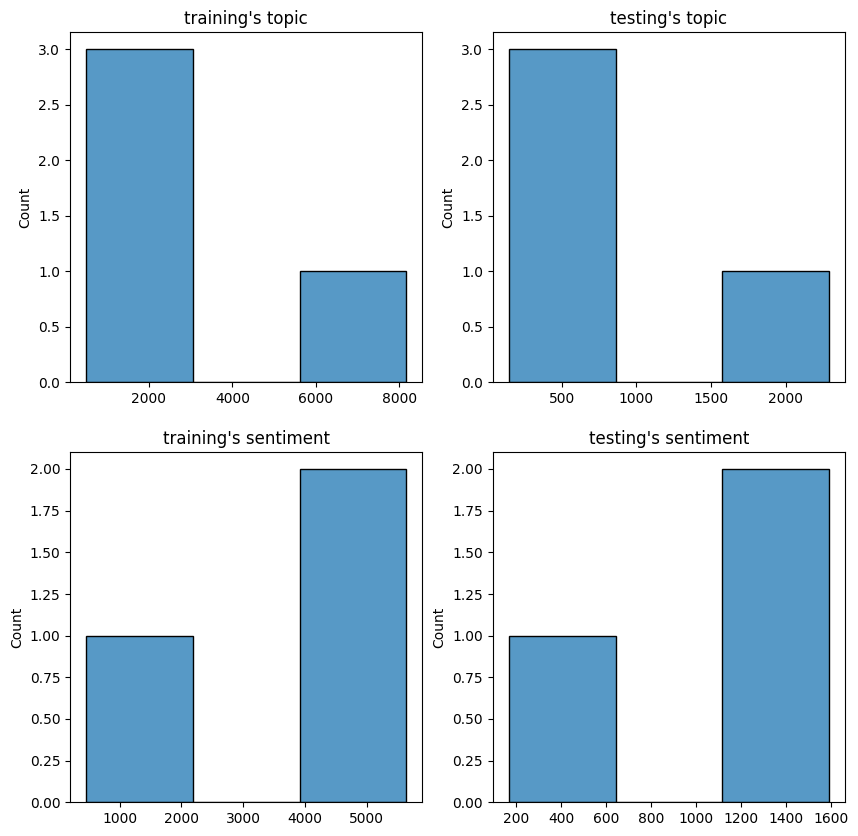

In [35]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def visualization(train_set, test_set, feature_to_plot):
  len_f = len(feature_to_plot)
  fig, axes = plt.subplots(ncols = 2, nrows = len_f, figsize = (10, len_f*5))
  for i,feature in enumerate(feature_to_plot):
    train_counter = Counter(train_set[feature])
    test_counter = Counter(test_set[feature])
    sns.histplot(train_counter, ax = axes[i,0]).set_title(f"training's {feature}")
    sns.histplot(test_counter, ax = axes[i,1]).set_title(f"testing's {feature}")

  plt.show()
visualization(train_set, test_set, set(train_set.features) - {'sentence'})

## Custom dataset

In [ ]:
from multiprocessing import Value
from torch.utils.data import dataset
import torch
from transformers  import AutoTokenizer

class Mydataset(dataset):

  def __init__(self, dataset_name : str,
               tokenizer_name: str,
               max_length : int,
               target_name = "sentiment") :
      """
      Args:
        name (str): The dataset name to load from hugging_face
        tokenizer_name (str): NName of the Hugging Face tokenizer to use
        max_length (int):Maximum sequence length for tokenization.
      """

      super().__init__()

      #1. Load the Hugging Face dataset
      self.mydataset = load_dataset(dataset_name)
      self.train_set = self.mydataset["train"]
      self.test_set = self.mydataset["test"]

      #2. Load the tokenizer and do some initialize thing
      self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
      self.max_length = max_length

      #3. Create label mapping for labels (incase it was not numeric value)
      self.label_names = self.mydataset.features[target_name].names
      self.label_to_id = {label : i for i,label in enumerate(self.label_names)}
      self.id_to_label = {i: label for i, label in enumerate(self.label_names)}
      self.num_labels = len(self.label_names)

  def __len__(self):

    """
    returns the total number of samples in dataset.
    """
    return len(self.mydataset)

  def __getitem__(self,idx):
    """
    returns a signle processed sample from the dataset at the given index.
    Args:
      idx (int): Index of the sample to retrieve.
    Returns:
      dict: A dictionary containing:
        - 'input_ids': Tokenized input setence.
        - 'attention_mask': Attention mask for the tokenizeed sentence.
        - 'labels': Integer representation of the sentiment label.
    """

    # 1. Take out the sample arcoding to the given index idx
    sample = self.mydataset[idx]
    sentence = sample['sentence']
    sentiment_str = sample['sentiment']

    # 2. Extract the label, we convert it into numeric value incase it was string.
    if isinstance(sentiment_str, str):
      label_id = self.label_to_id[sentiment_str]
    elif isinstance(sentiment_str, int):
      label_id = sentiment_str
    else
      raise ValueError(f"Unexpected sentiment type: {type(sentiment_str)} for value {sentiment_str}")

    #3. tokenize the sentence
    encoding = self.tokenizer(
        sentence,
        padding = 'max_length',
        truncation = True,
        max_length = self.max_length,
        return_attention_mask = True,
        return_tensors = 'pt'
    )

    return {
        'input_ids': encoding['input_ids'].squeeze(0),
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'labels' : torch.tensor(label_id, dtype = torch.long)
    }









# Question:

For both BERT - XLNet and vietnamese texts (this homework) and english texts (previous homework):
- Are there any differences in the evaluating performance in applying those 2 models for 2 datasets, i.e., vietnamese and english ? Analyze and visualize your results to prove your conclusion.
- How to improve the weaker approaches ?